### Model Training: Support Vector Machine(SVM) & Extreme Gradient Boosting(XGBoost)

#### 1. Setup

In [149]:
#Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#### 2. Load The Data

In [136]:
df = pd.read_csv("../data/cleaned_data.csv")

In [137]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 3. Data Preprocessing

##### 3.1 Binary Encoding

* First converts categorical data into integers, then converts these numbers to the binary (0 and 1) number system and separates them into different columns.

In [138]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Female': 1, 'Male': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

In [139]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


##### 3.2 Ordinal Encoding

* Represents categories (ordered data) with integers (such as 0, 1, 2) in a meaningful logical order; used when there is a natural greater-than or hierarchical relationship in the data.

In [140]:
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

##### 3.3 One-Hot Encoding

* Converts categorical variables (data with no hierarchical relationship) into a numerical format by creating a separate column for each category (with values ​​of 0 or 1); suitable for cases where there is no hierarchy between categories (nominal).

In [141]:
df = pd.get_dummies(data=df, columns=['PaymentMethod', 'InternetService'], drop_first=True, dtype=int)

* When you set `drop_first=True`, it removes one of the categories (for example, it discards the 'Male' column). If the 'Female' column is 0, the model automatically says "This person must be Male". This improves the model's performance and eliminates unnecessary column redundancy.

In [142]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,1,0,1,0,1,0,0,0,1,0,...,0,1,29.85,29.85,0,0,1,0,0,0
1,0,0,0,0,34,1,0,1,0,1,...,1,0,56.95,1889.50,0,0,0,1,0,0
2,0,0,0,0,2,1,0,1,1,0,...,0,1,53.85,108.15,1,0,0,1,0,0
3,0,0,0,0,45,0,0,1,0,1,...,1,0,42.30,1840.75,0,0,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,70.70,151.65,1,0,1,0,1,0


#### 3.4 Feature Scaling

#### 4. Model Training

In [143]:
# Split dataset into X and y



X = df.drop('Churn', axis=1)  # Features
y = df['Churn']               # Target


print("X shape:", X.shape)
print("y shape:", y.shape)
# data into train and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

X shape: (7043, 22)
y shape: (7043,)


In [144]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
# 1. Eğitim setindeki sütunları fit_transform ile ölçeklendir
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# 2. Test setindeki sütunları SADECE transform ile ölçeklendir (Eğitimden öğrendiği değerleri kullanır)
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [145]:
# Initialize an empty list to store model scores



model_scores = []

# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),  # Add hyperparameters for Random Forest
    ('Support Vector Machine', SVC(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__gamma': ['scale', 'auto']}),  # Add hyperparameters for SVM
    ('Logistic Regression', LogisticRegression(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__penalty': ['l1', 'l2']}),  # Add hyperparameters for Logistic Regression
    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),  # Add hyperparameters for KNN
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'model__max_depth': [None, 10, 20],
         'model__min_samples_split': [2, 5, 10]}),  # Add hyperparameters for Decision Tree
    ('XG Boost', XGBClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),  # Add hyperparameters for XG Boost
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),  # Feature Scaling
        ('model', model)
    ])

# Hyperparameter tuning using GridSearchCV
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2)
        grid_search.fit(X_train, y_train)
        pipeline = grid_search.best_estimator_

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

      # Convert the list to a DataFrame
    scores_df = pd.DataFrame(model_scores)
    # Print the performance metrics
    print("Model:", name)
    print("Test Accuracy:", round(accuracy, 3), "%")
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the overall best model
print("Best Model:")
print("Test Accuracy:", best_accuracy)
print("Model Pipeline:", best_model, "with accuracy", round(best_accuracy,2), "%")

Model: Random Forest
Test Accuracy: 0.8 %

Model: Support Vector Machine
Test Accuracy: 0.747 %

Model: Logistic Regression
Test Accuracy: 0.74 %

Model: K-Nearest Neighbors
Test Accuracy: 0.765 %

Model: Decision Tree
Test Accuracy: 0.766 %

Model: XG Boost
Test Accuracy: 0.803 %

Best Model:
Test Accuracy: 0.8034066713981547
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interactio

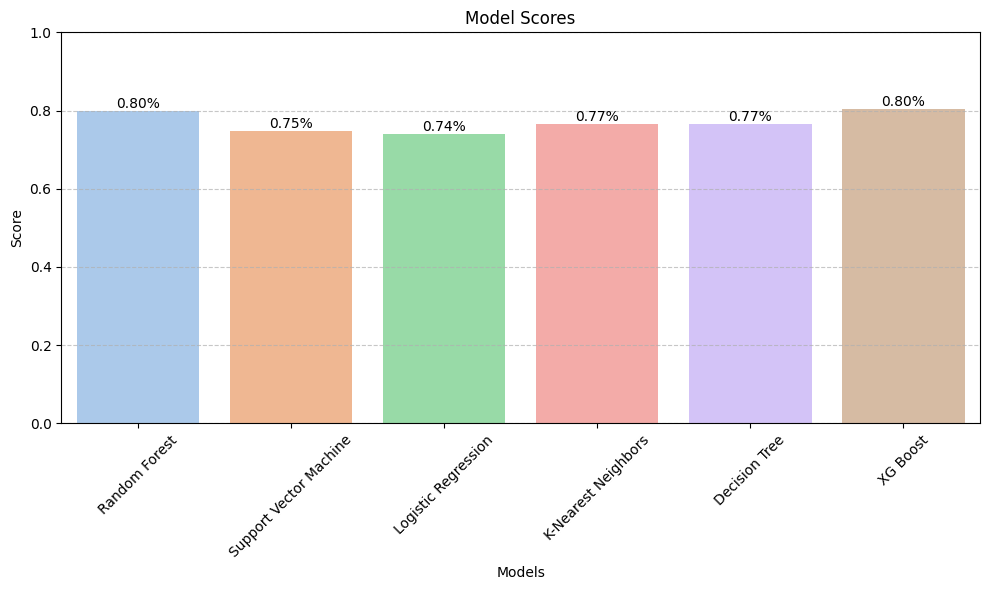

In [146]:
# Define a color palette for the bars
#colors = sns.color_palette('pastel', n_colors=len(scores_df))

# Create a bar plot of models and their scores




plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=scores_df, palette="pastel")

# Add text on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')
    
plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 5. Improve SVM Model

In [147]:
# 1. Model Tanımlama
# probability=True: Daha sonra ROC-AUC eğrisi çizdirmek istersen olasılık değerlerine ihtiyacın olacak.
# class_weight='balanced': Churn olan azınlık sınıfına otomatik olarak daha fazla ağırlık verir.
svm_model = SVC(probability=True, class_weight='balanced', random_state=42)

# 2. Hiperparametre Seti
# C: Hata payı toleransı (Düşük C: Geniş sınır, yüksek C: Veriye sıkı uyum)
# gamma: Karar sınırının ne kadar 'esnek' olacağı
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

# 3. GridSearchCV Kurulumu
# scoring='f1': Sadece doğruluğa değil, gidenleri yakalama başarısına (F1) odaklanıyoruz.
grid_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# 4. Eğitim (Daha önce oluşturduğumuz ölçeklendirilmiş veriyi kullanıyoruz)
grid_svm.fit(X_train, y_train)

# En iyi parametreleri yazdıralım
print("En iyi parametreler:", grid_svm.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
En iyi parametreler: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


In [150]:
# 5. En iyi modelle tahmin yapma
y_pred_svm = grid_svm.predict(X_test)

# 6. Sonuçların Raporlanması
print("--- SVM Performans Raporu ---")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# Doğruluk skoru yerine özellikle 'Recall' ve 'F1-Score' değerlerine bak

--- SVM Performans Raporu ---
[[742 293]
 [ 77 297]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Bu Bölümde Dikkat Etmen Gerekenler:
Neden F1-Score? Telco verisinde "Müşteri kalacak" diyerek %80 başarıyı yakalamak kolaydır. Asıl başarı, gerçekten gidecek olan (1 sınıfı) müşterileri kaçırmamaktır. Recall değeri, gideceklerin yüzde kaçını bildiğini gösterir.

Kernel Seçimi: Eğer linear kernel en iyi sonucu veriyorsa, verin doğrusal olarak ayrılabilir demektir. Ancak genellikle rbf (Radial Basis Function) karmaşık müşteri davranışlarını daha iyi yakalar.

İşlem Süresi: SVM, veri boyutu arttıkça yavaşlayabilir. Eğer n_jobs=-1 kullanırsan bilgisayarının tüm çekirdeklerini kullanarak işlemi hızlandırabilirsin.

3. Model Karşılaştırma ve Final (En Önemli Kısım)
İki modeli de ayrı ayrı eğittikten sonra, en sonda bir "Model Comparison" bölümü açarak ikisini aynı ringe çıkar:

Her iki modelin Confusion Matrix'ini yan yana koy.

F1-Score ve Recall (Giden müşteriyi yakalama oranı) değerlerini karşılaştır.

Hangi modelin "neden" daha iyi sonuç verdiğine dair bir yorum ekle (Örneğin: "XGBoost kategorik verilerle daha iyi başa çıktı" gibi).

#### Improve XGBoost Model

In [151]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# 1. Dengesiz veri setini yönetmek için ağırlık hesaplama
# Formül: Negatif Sınıf Sayısı / Pozitif Sınıf Sayısı
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

# 2. Model Tanımlama
xgb_model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    scale_pos_weight=scale_weight, # Churn olanlara daha fazla önem verir
    use_label_encoder=False,
    eval_metric='logloss'
)

# 3. Hiperparametre Seti
param_grid_xgb = {
    'n_estimators': [100, 200],          # Ağaç sayısı
    'max_depth': [3, 5, 7],               # Ağaç derinliği (Overfitting kontrolü)
    'learning_rate': [0.01, 0.1, 0.2],    # Öğrenme hızı
    'subsample': [0.8, 1.0],              # Her ağaçta kullanılacak veri oranı
    'colsample_bytree': [0.8, 1.0]        # Her bölünmede kullanılacak özellik oranı
}

# 4. GridSearchCV Kurulumu
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# 5. Eğitim
# Not: XGBoost ölçeklenmiş veriyle de çalışır, karşılaştırma tutarlılığı için X_train_scaled kullanabilirsin.
grid_xgb.fit(X_train, y_train)

print("XGBoost En İyi Parametreler:", grid_xgb.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
XGBoost En İyi Parametreler: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


--- XGBoost Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



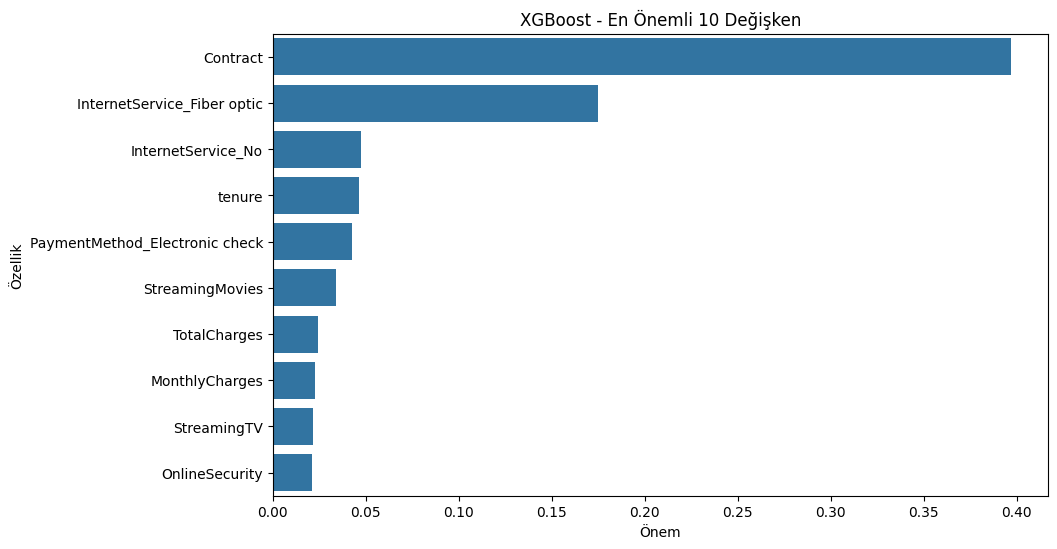

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. Tahmin yapma
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)

# 7. Performans Raporu
print("--- XGBoost Performans Raporu ---")
print(classification_report(y_test, y_pred_xgb))

# 8. Feature Importance Görselleştirme
best_xgb = grid_xgb.best_estimator_
features = X.columns
importances = best_xgb.feature_importances_

# Önem sırasına göre dataframe oluşturup çizdirelim
feature_imp_df = pd.DataFrame({'Özellik': features, 'Önem': importances}).sort_values(by='Önem', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Önem', y='Özellik', data=feature_imp_df.head(10)) # İlk 10 özelliği görelim
plt.title('XGBoost - En Önemli 10 Değişken')
plt.show()